In [2]:
# Instalar YOLOv8
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
print("YOLO listo v")

YOLO listo v


In [4]:
# Verificamos que PyTorch detecta la GPU de Google
# Si sale True, el entrenamiento será rápido
# Si sale False, estamos en CPU y entrenar tardará mucho
import torch
print("GPU disponible:", torch.cuda.is_available())
print("Nombre de GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU disponible: True
Nombre de GPU: Tesla T4


In [6]:
# Instalamos la librería de Kaggle para poder descargar datasets
# Kaggle requiere autenticación para descargar datos
!pip install kaggle

In [7]:
# Subimos el archivo kaggle.json al entorno de Colab
# Esto le da permiso para descargar datasets de Kaggle
import os
os.makedirs('/root/.kaggle', exist_ok=True)

In [10]:
# Montamos Google Drive en el entorno de Colab
# Esto nos da acceso a todos nuestros archivos de Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
# Cargamos las credenciales desde el .env guardado en Drive
# Así nunca exponemos la key en el código
import os
from dotenv import load_dotenv

# Ruta al .env en tu Drive - ajusta si lo pusiste en otra carpeta
load_dotenv('/content/drive/MyDrive/CAELESTIS/.env')

os.makedirs('/root/.kaggle', exist_ok=True)

import json
kaggle_config = {
    "username": os.getenv("KAGGLE_USERNAME"),
    "key": os.getenv("KAGGLE_KEY")
}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Credenciales Kaggle configuradas ✓")
print("Usuario:", os.getenv("KAGGLE_USERNAME"))

Credenciales Kaggle configuradas ✓
Usuario: yessliah


In [18]:
# Descargamos el dataset COSMICA desde Kaggle
# piratinskii es el usuario, astronomical-object-detection es el nombre del dataset
!kaggle datasets download -d piratinskii/astronomical-object-detection --unzip -p /content/cosmica

Dataset URL: https://www.kaggle.com/datasets/piratinskii/astronomical-object-detection
License(s): unknown
100% 1.04G/1.04G [00:12<00:00, 87.9MB/s]



In [19]:
# Exploramos la estructura del dataset descargado
# Ver cómo están organizadas las carpetas e imágenes
import os

for root, dirs, files in os.walk('/content/cosmica'):
    level = root.replace('/content/cosmica', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')
            

cosmica/
  yolov11_balanced/
    dataset.yaml
    train/
      images/
      labels/
    valid/
      images/
      labels/
    test/
      images/
      labels/


In [20]:
with open('/content/cosmica/yolov11_balanced/dataset.yaml', 'r') as f:
    print(f.read())

train: train/images
val: valid/images
test: test/images

nc: 4
names: ['comet', 'galaxy', 'globular_cluster', 'nebula']


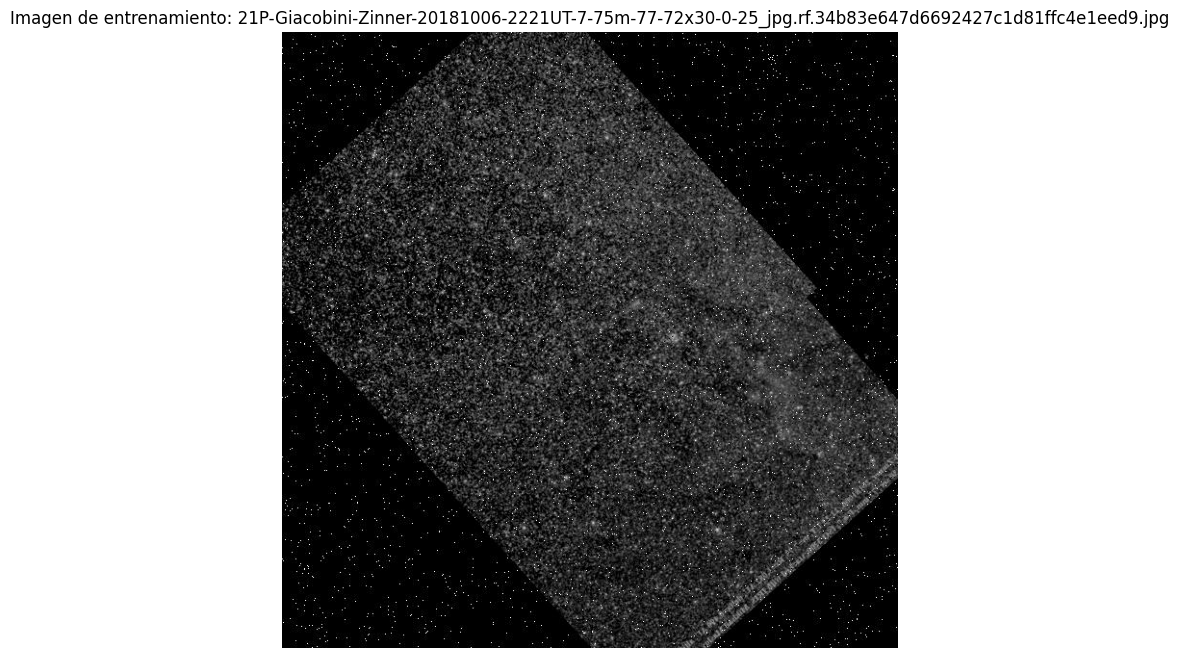

Dimensiones: (640, 640, 3)
Total imágenes entrenamiento: 15589


In [21]:
# Visualizamos una imagen del dataset con sus anotaciones
# Para entender cómo lucen los datos antes de entrenar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Tomamos la primera imagen del conjunto de entrenamiento
train_images = os.listdir('/content/cosmica/yolov11_balanced/train/images')
img_path = f'/content/cosmica/yolov11_balanced/train/images/{train_images[0]}'

img = mpimg.imread(img_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.title(f'Imagen de entrenamiento: {train_images[0]}')
plt.axis('off')
plt.show()

print(f"Dimensiones: {img.shape}")
print(f"Total imágenes entrenamiento: {len(train_images)}")